In [21]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
from scipy.special import softmax
from scipy.optimize import minimize_scalar
from scipy.linalg import norm
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
import numpy as np
from common.ffn.ffn_relu import ParametricReLUNet
from common.ffn.ffn_base import FFNGmetricLogging
import libs.ntk_ffn as ntk_ffn
from sklearn.metrics import mean_squared_error
from random import randrange
from util import *

from torchvision.datasets import EMNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

import logging

In [22]:
logging.basicConfig(filename="log_criticality_step2_eminst.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s",
                datefmt="%m/%d/%Y %I:%M:%S")


#### MNIST dataset

MNIST dataset is used which contains 60000 28x28 images of handwritten digits from 0 to 9. 

In [23]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root='./', split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root='./', split='letters', train=False, download=True, transform=image_transform)

In [24]:
BATCH_SIZE = 96 #128 #64 #

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
)

Data example:

Feature batch shape: torch.Size([96, 1, 28, 28])
Labels batch shape: torch.Size([96])
Labels: [[4, 22, 18, 22, 1, 15, 14, 3], [22, 9, 25, 6, 20, 5, 12, 7], [1, 20, 16, 5, 5, 20, 8, 25], [10, 26, 7, 2, 25, 26, 12, 25], [26, 13, 8, 20, 17, 4, 25, 1], [25, 13, 1, 23, 24, 22, 1, 10], [26, 15, 21, 22, 7, 4, 10, 18], [14, 23, 24, 9, 2, 26, 24, 23], [25, 2, 1, 13, 7, 4, 22, 24], [24, 11, 16, 14, 22, 25, 13, 21], [17, 19, 25, 16, 19, 6, 16, 9], [3, 14, 1, 5, 26, 14, 13, 16]]


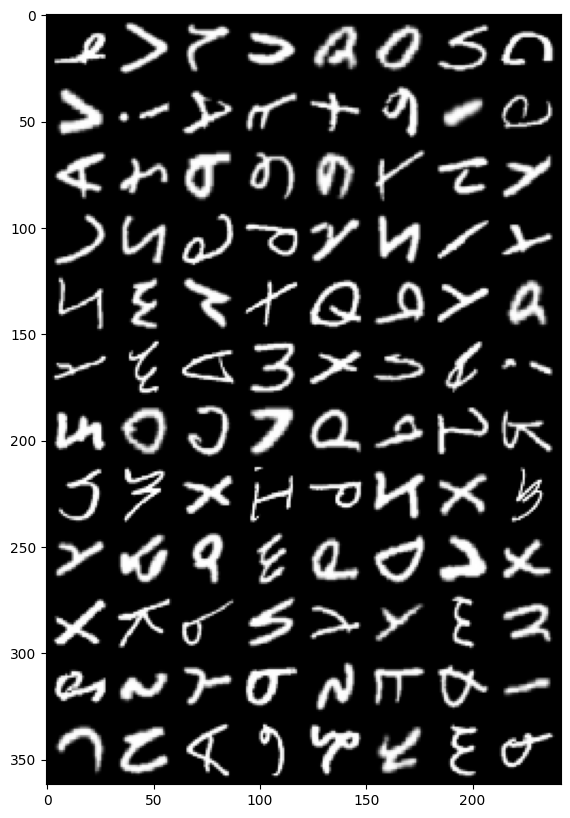

In [25]:
GRID_ROW_SIZE=8
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
#img = train_features[0].squeeze()
images = make_grid(train_features, GRID_ROW_SIZE).permute(1, 2, 0)
labels = train_labels.view(-1, GRID_ROW_SIZE).tolist()
print(f"Labels: {labels}")
plt.figure(figsize=(20, 10))
plt.imshow(images, cmap="gray")
plt.show()


In [26]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 250, 100

lb, lw = 1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
#lambdas as from (8.5)
lw_input, lw_hidden, lw_output = lw/INPUT_DIM, lw/INPUT_WIDTH, lw/HIDDEN_WIDTH

##### UTILS

In [27]:
def loss_crossentropy(zz_logits, true_labels):
    qq = softmax(zz_logits, axis=(0))
    #pp_raw = true_labels.detach().numpy()
    pp = np.zeros_like(qq)
    for col in range(len(true_labels)):
        pp[true_labels[col],col]=1
    return -np.sum(pp * np.log(qq))/len(true_labels)

def labels_to_onehot(labels, logits):
    batch_size = labels.shape[0]
    yy = np.zeros((OUTPUT_DIM, batch_size))
    for batch_num in range(batch_size):
        for output_num in range(OUTPUT_DIM):
            yy[output_num, batch_num] = \
                max(1.0, logits[batch_num, output_num]) \
                    if output_num == labels[batch_num] \
                    else min(-1.0, logits[batch_num, output_num])

    logging.debug("For labels\n{}\nlogits are:\n{}".format(labels, yy))
    return yy

def visualise():
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].set_title('Loss (cross-entropy)')
    axes[0].plot(HISTORY_PARAMS['train_loss'], label='Train Loss')
    axes[0].plot(HISTORY_PARAMS['test_loss'], label='Test Loss')
    axes[0].grid()
    axes[0].legend(fontsize=20)
    
    axes[1].set_title('Accuracy')
    axes[1].plot(HISTORY_PARAMS['train_accuracy'], label='Train Accuracy')
    axes[1].plot(HISTORY_PARAMS['test_accuracy'], label='Test Accuracy')
    axes[1].grid()
    axes[1].legend(fontsize=20)

    fig2, ax2 = plt.subplots(1, 1, figsize=(20, 6))
    ax2.set_title('Train-step eta')
    ax2.plot(HISTORY_PARAMS['train_eta']) #, label='Train-step eta'
    ax2.grid()
    #ax2.legend(fontsize=20)    
    
    plt.show()

HISTORY_PARAMS = collections.defaultdict(list)

In [28]:
class NTKCalculator:
    def __init__(self):
        self.input_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH, INPUT_DIM))
        self.input_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH))
        self.hidden_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH, INPUT_WIDTH))
        self.hidden_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH))
        self.output_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM, HIDDEN_WIDTH))
        self.output_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM))

    def calculate_derivatives(self, testNet, logits):
        for kk, alpha in itr.product(range(OUTPUT_DIM), range(BATCH_SIZE)):
            df = torch.autograd.grad(logits[alpha,kk], (testNet.input_fc.weight, testNet.input_fc.bias\
                                            , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                            , testNet.output_fc.weight, testNet.output_fc.bias)\
                , retain_graph=True, create_graph=True, allow_unused=True)
            self.input_dweight[kk, alpha] = df[0].detach().numpy()
            self.input_dbias[kk, alpha] = df[1].detach().numpy()
            self.hidden_dweight[kk, alpha] = df[2].detach().numpy()
            self.hidden_dbias[kk, alpha] = df[3].detach().numpy()
            self.output_dweight[kk, alpha] = df[4].detach().numpy()
            self.output_dbias[kk, alpha] = df[5].detach().numpy()

    def calculate_average_NTK(self, HL):
        HL_avg = np.zeros((BATCH_SIZE, BATCH_SIZE))
        for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
            value_avg = np.average([HL[num, num, alpha1, alpha2] for num in np.arange(OUTPUT_DIM)])
            HL_avg[alpha1, alpha2] = value_avg

        return HL_avg

    def calculate_NTK(self):
        input_dbias_sum = lb * np.tensordot(self.input_dbias, self.input_dbias, axes=([2],[2]))
        input_dweight_sum = lw_input * np.tensordot(self.input_dweight, self.input_dweight, axes=([2,3],[2,3]))
        hidden_dbias_sum = lb * np.tensordot(self.hidden_dbias, self.hidden_dbias, axes=([2],[2]))
        hidden_dweight_sum = lw_hidden * np.tensordot(self.hidden_dweight, self.hidden_dweight, axes=([2,3],[2,3]))        
        output_dbias_sum = lb * np.tensordot(self.output_dbias, self.output_dbias, axes=([2],[2]))
        output_dweight_sum = lw_output * np.tensordot(self.output_dweight, self.output_dweight, axes=([2,3],[2,3]))
        summary = input_dbias_sum+input_dweight_sum+hidden_dbias_sum+hidden_dweight_sum+output_dbias_sum+output_dweight_sum
        return np.moveaxis(summary, 1, 2)
        '''
        input_dbias_sum = lb * np.einsum('abx,cdx->acbd', self.input_dbias, self.input_dbias)
        input_dweight_sum = lw_input * np.einsum('abxy,cdxy->acbd', self.input_dweight, self.input_dweight)
        hidden_dbias_sum = lb * np.einsum('abx,cdx->acbd', self.hidden_dbias, self.hidden_dbias)
        hidden_dweight_sum = lw_hidden * np.einsum('abxy,cdxy->acbd', self.hidden_dweight, self.hidden_dweight)
        output_dbias_sum = lb * np.einsum('abx,cdx->acbd', self.output_dbias, self.output_dbias)
        output_dweight_sum = lw_output * np.einsum('abxy,cdxy->acbd', self.output_dweight, self.output_dweight)
        return input_dbias_sum+input_dweight_sum+hidden_dbias_sum+hidden_dweight_sum+output_dbias_sum+output_dweight_sum
        '''

    def calculate_ID(self):
        ID = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
        for kk, alpha in itr.product(range(OUTPUT_DIM), range(OUTPUT_DIM)):
            ID[kk, kk, alpha, alpha] = 1
        return ID

NTK_RECALC_STEPS_PERIOD = 5

class StepCalculatorBase:
    def __init__(self):
        self.delta_weight_00 = None
        self.delta_bias_00 = None
        self.delta_weight_01 = None
        self.delta_bias_01 = None
        self.delta_weight_02 = None
        self.delta_bias_02 = None

    def do_step0(self, testNet, delta = 1.0):
        with torch.no_grad():
            testNet.input_fc.weight += torch.from_numpy(self.delta_weight_00) * delta
            testNet.input_fc.bias += torch.from_numpy(self.delta_bias_00) * delta
            testNet.hidden_fc.weight += torch.from_numpy(self.delta_weight_01) * delta
            testNet.hidden_fc.bias += torch.from_numpy(self.delta_bias_01) * delta
            testNet.output_fc.weight += torch.from_numpy(self.delta_weight_02) * delta
            testNet.output_fc.bias += torch.from_numpy(self.delta_bias_02) * delta

class StepCalculatorForGradient(StepCalculatorBase):
    def __init__(self):
        super().__init__()

    def step(self, testNet, labels, logits, etas):
        yy = labels_to_onehot(labels, logits.detach())
        zz = np.transpose(logits.detach().numpy())
        delta = zz - yy

        calc0 = NTKCalculator()
        calc0.calculate_derivatives(testNet, logits)
        do_calc_eta = (etas[0] == 0.0 or NTK_RECALC_STEPS_PERIOD == 0)
        if (do_calc_eta == False):
            do_calc_eta = randrange(NTK_RECALC_STEPS_PERIOD) == 0

        eta = 0.0
        if (do_calc_eta):
            logging.info("##Calculating NTK by (8.4)")
            HL = calc0.calculate_NTK()
            ID = calc0.calculate_ID()
            logging.info("##Calculating η minimising (∞.86)")
            fun = lambda eta: norm(np.tensordot(ID - eta*HL, delta, axes=([1,3],[0,1])), ord='fro')
            res = minimize_scalar(fun, bounds=(0, 1000))
            logging.info("##Optimal point found: {}".format(res))
            logging.info("##Step ratio: {}".format(res.fun/norm(delta, ord='fro')))
            if etas[0] == 0.0:
                etas[1] = res.x
            else:
                etas[1] = etas[0]
            etas[0] = res.x
            eta = res.x
        else:
            eta = round(0.6 * etas[0] + 0.4 * etas[1], 5);
            logging.info("##Using previous eta value={}".format(eta))
        #(7.11)

        term = -1*eta*delta
        self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=([0,1],[0,1])) * lw_input
        self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=([0,1],[0,1])) * lb
        self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=([0,1],[0,1])) * lw_hidden
        self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=([0,1],[0,1])) * lb
        self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=([0,1],[0,1])) * lw_output
        self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=([0,1],[0,1])) * lb        
        '''
        self.delta_weight_00 = np.einsum('xy,xyab->ab', term, calc0.input_dweight) * lw_input
        self.delta_bias_00 = np.einsum('xy,xya->a', term, calc0.input_dbias) * lb
        self.delta_weight_01 = np.einsum('xy,xyab->ab', term, calc0.hidden_dweight) * lw_hidden
        self.delta_bias_01 = np.einsum('xy,xya->a', term, calc0.hidden_dbias) * lb
        self.delta_weight_02 = np.einsum('xy,xyab->ab', term, calc0.output_dweight) * lw_output
        self.delta_bias_02 = np.einsum('xy,xya->a', term, calc0.output_dbias) * lb
        '''
        
        self.do_step0(testNet)
        return etas


##### Implementation for one-step impirical minimisation, consists of 2 substeps: big step and small step

#### FFN

Typical implementation of image-recognition

FFN with 2 hidden layers: 
- nn.ReLU is an activation-function
- nn.

Cross-entropy loss and stochastic gradient descent optimiser are used. Descent is performed in number of epochs, no stop-criterion for gradient descent. Accuracy is the metric for the learninng process.

In [29]:
class MNISTReLU(ParametricReLUNet):
    def __init__(self, input_dim, output_dim):
        super().__init__(n0=input_dim,nk=0,nl=output_dim,l=0, bias_on=True)

        self.input_fc = nn.Linear(input_dim, INPUT_WIDTH)
        self.hidden_fc = nn.Linear(INPUT_WIDTH, HIDDEN_WIDTH)
        self.output_fc = nn.Linear(HIDDEN_WIDTH, output_dim)

    def forward_(self, x):
        return self.forward(x)

    def forward(self, x):
        #x = [batch size, height * width]
        h_1 = self.PReLU(self.input_fc(x))
        #h_1 = [batch size, INPUT_WIDTH]
        h_2 = self.PReLU(self.hidden_fc(h_1))
        #h_2 = [batch size, HIDDEN_WIDTH]
        y_pred = self.output_fc(h_2)
        #y_pred = [batch size, output dim]
        return y_pred
    
    def init_weights(self, cb=0.0, cw=1.0):
        if self.get_log_level() == "debug":
            logging.debug("FeedForwardNet weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        self.init_linear_weights(self.input_fc, self.bias_on, cb, cw/self.input_fc.in_features)
        self.init_linear_weights(self.hidden_fc, self.bias_on, cb, cw/self.hidden_fc.in_features)
        self.init_linear_weights(self.output_fc, self.bias_on, cb, cw/self.output_fc.in_features)

    def grad_zero(self):
        self.input_fc.weight.grad.zero_()
        self.input_fc.bias.grad.zero_()
        self.hidden_fc.weight.grad.zero_()
        self.hidden_fc.bias.grad.zero_()
        self.output_fc.weight.grad.zero_()
        self.output_fc.bias.grad.zero_()

    def save_txt(self, dir_name):
        np.savetxt(dir_name + '/input_weight.out', self.input_fc.weight.detach().numpy(), delimiter=',')
        np.savetxt(dir_name + '/input_bias.out', self.input_fc.bias.detach().numpy(), delimiter=',')
        np.savetxt(dir_name + '/hidden_weight.out', self.hidden_fc.weight.detach().numpy(), delimiter=',')
        np.savetxt(dir_name + '/hidden_bias.out', self.hidden_fc.bias.detach().numpy(), delimiter=',')
        np.savetxt(dir_name + '/output_weight.out', self.output_fc.weight.detach().numpy(), delimiter=',')
        np.savetxt(dir_name + '/output_bias.out', self.output_fc.bias.detach().numpy(), delimiter=',')

    def init_weights_txt(self, dir_name):
        self.init_linear_zeros(self.input_fc, self.bias_on)
        self.init_linear_zeros(self.hidden_fc, self.bias_on)
        self.init_linear_zeros(self.output_fc, self.bias_on)
        calc0 = StepCalculatorBase()
        calc0.delta_weight_00 = np.loadtxt(dir_name + '/input_weight.out', delimiter=',')
        calc0.delta_bias_00 = np.loadtxt(dir_name + '/input_bias.out', delimiter=',')
        calc0.delta_weight_01 = np.loadtxt(dir_name + '/hidden_weight.out', delimiter=',')
        calc0.delta_bias_01 = np.loadtxt(dir_name + '/hidden_bias.out', delimiter=',')
        calc0.delta_weight_02 = np.loadtxt(dir_name + '/output_weight.out', delimiter=',')
        calc0.delta_bias_02 = np.loadtxt(dir_name + '/output_bias.out', delimiter=',')        
        calc0.do_step0(self)


#### Experiment with FFN in criticality mode for relu

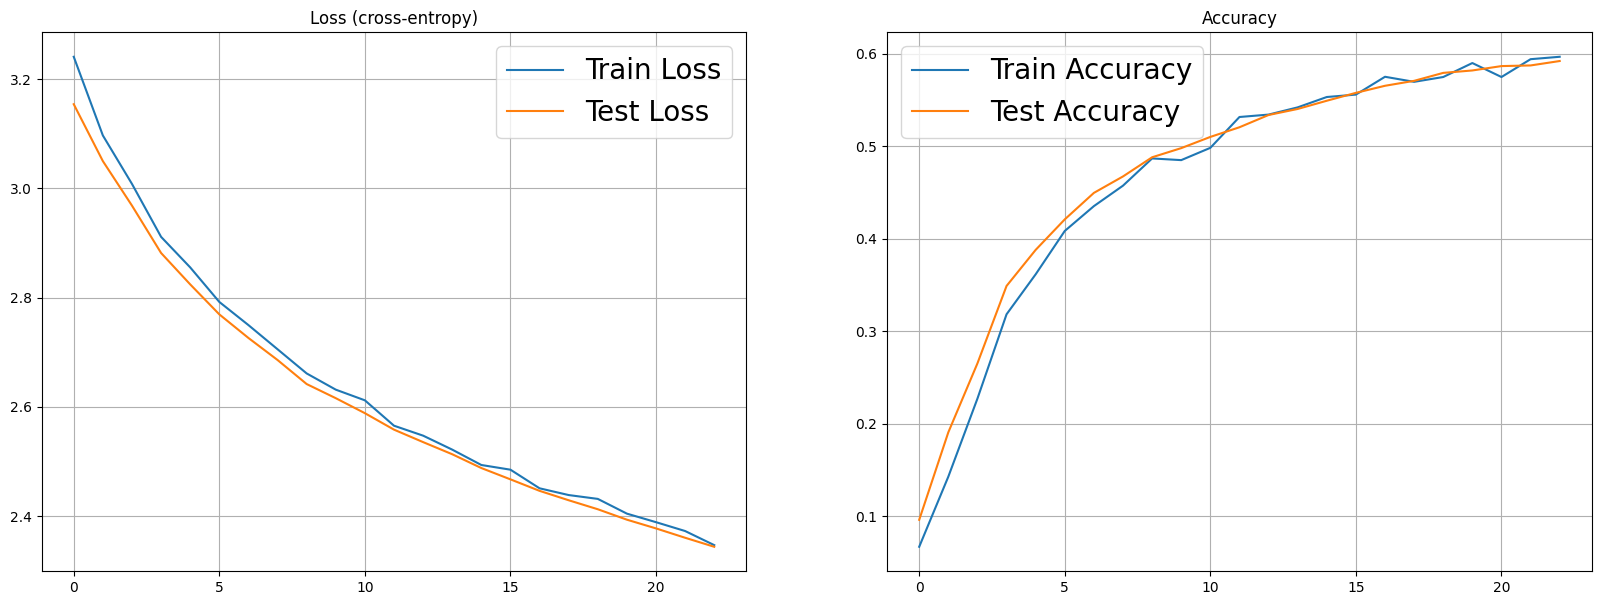

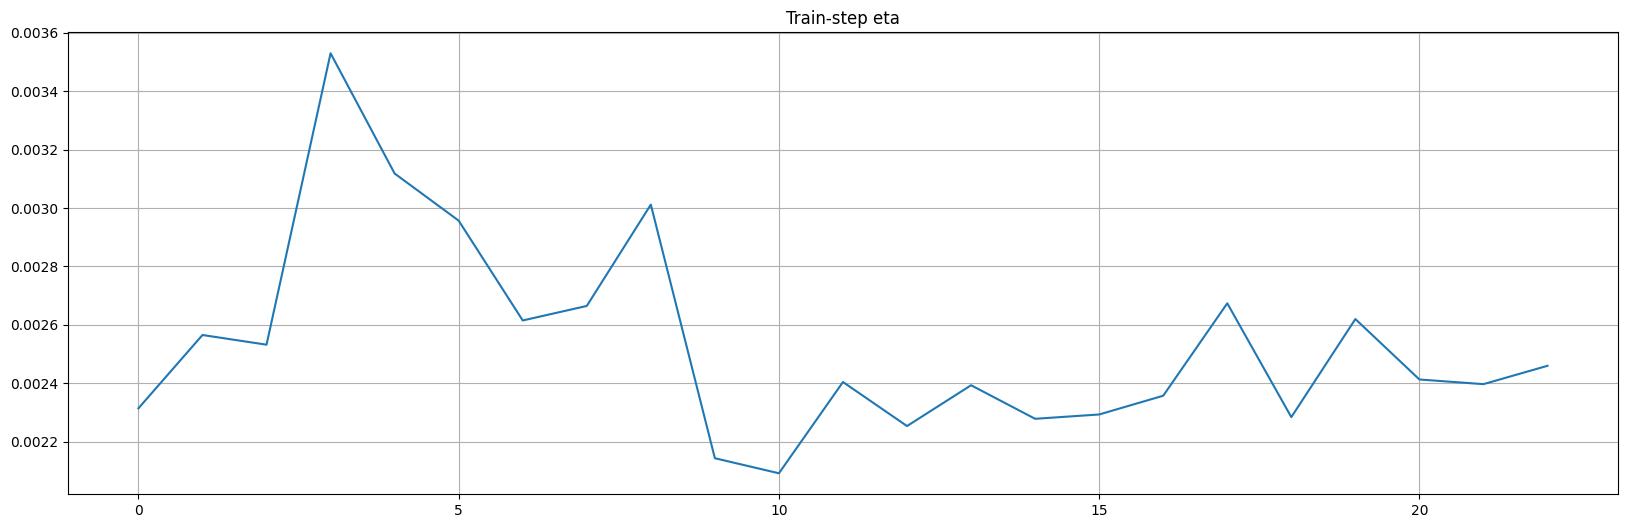

Test accuracy = 0.5920218892292493
!! tensor(20)


KeyboardInterrupt: 

In [30]:
NUM_EPOCH = 1000 #50
HISTORY_PARAMS = collections.defaultdict(list)

#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

DEVICE = torch.device('cpu')  # you can change to `cuda:0`
testNet = MNISTReLU(INPUT_DIM, OUTPUT_DIM)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
#testNet.init_weights_txt('ffn_saved/accuracy_90')
testNet.init_weights(cb, cw)
testNet.to(DEVICE)

etas = [0.0, 0.0]
for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    # Check implementation in `utils.py`
    train_loss_meter, train_accuracy_meter, test_loss_meter, test_accuracy_meter, eta_meter = \
        AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        if iter_number >= 40:
            break
        iter_number += 1        
        stepCalc0 = StepCalculatorForGradient()
        images, labels_raw = train_batch
        if (iter_number == 1):
            print("!!", labels_raw[0])
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)
        testNet.grad_zero
        logits = testNet.forward_(xx)
        etas = stepCalc0.step(testNet, labels, logits, etas)
        eta_meter.update(etas[0])

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits.detach().numpy())
        prediction = logits.argmax(dim=-1).detach()
        loss = loss_crossentropy(zz_logits, labels)
        train_loss_meter.update(loss)
        train_accuracy_meter.update(
            calculate_accuracy(
                prediction,
                labels
            )
        )
    # save average train loss and accuracy
    HISTORY_PARAMS['train_loss'].append(train_loss_meter.avg)
    HISTORY_PARAMS['train_accuracy'].append(train_accuracy_meter.avg)
    HISTORY_PARAMS['train_eta'].append(eta_meter.avg)

    # testing loop
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)        
        with torch.no_grad():
            # do everything like we did in training loop
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(
                calculate_accuracy(
                    prediction,
                    labels
                )
            )

    # save average test accuracy loss and accuracy
    HISTORY_PARAMS['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise()
    print("Test accuracy = {}".format(test_accuracy_meter.avg))
    

In [ ]:
#testNet.save_txt('ffn_saved/current')

In [ ]:
print("Accuracy achieved in FFN at Relu-criticality: "+str(HISTORY_PARAMS['test_accuracy'][-1]))

IndexError: list index out of range

: 